## 2.1 理论计算题

### 1. 非线性激活函数的重要性

**已知：**  
- 输入：\( x \)  
- 隐藏层（无激活函数）：\( h = W_1 x + b_1 \)  
- 输出层：\( o = W_2 h + b_2 \)

**推导：**

将 \( h \) 代入 \( o \)：

\[
o = W_2 (W_1 x + b_1) + b_2
\]

\[
o = (W_2 W_1) x + W_2 b_1 + b_2
\]

令：
\[
W' = W_2 W_1
\]
\[
b' = W_2 b_1 + b_2
\]

则：
\[
o = W' x + b'
\]

**结论：**  
这是一个单层线性网络（等价于线性回归或无激活函数的单层感知机）。如果没有非线性激活函数，多层线性变换可合并为单层线性变换，模型表达能力不会增强。

---

### 2. 激活函数性质分析

#### (1) Sigmoid 函数

**函数表达式：**
\[
\operatorname{Sigmoid}(x) = \frac{1}{1 + e^{-x}}
\]

**导数推导：**

\[
\operatorname{Sigmoid}'(x) = \frac{e^{-x}}{(1 + e^{-x})^2}
= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}}
= \operatorname{Sigmoid}(x) \cdot \left(1 - \operatorname{Sigmoid}(x)\right)
\]

**关系式：**
\[
\boxed{\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))}
\]

#### (2) tanh 函数

**函数表达式：**
\[
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
\]

**导数推导：**

\[
\tanh'(x) = \operatorname{sech}^2(x) = 1 - \tanh^2(x)
\]

**验证过程：**

\[
\tanh'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}
= \frac{4}{(e^x + e^{-x})^2}
= \frac{1}{\cosh^2(x)}
= 1 - \tanh^2(x)
\]

**关系式：**
\[
\boxed{\tanh'(x) = 1 - \tanh^2(x)}
]

100%|██████████| 26.4M/26.4M [00:10<00:00, 2.46MB/s]
100%|██████████| 29.5k/29.5k [00:01<00:00, 25.8kB/s]
100%|██████████| 4.42M/4.42M [00:40<00:00, 108kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9kB/s]


训练集大小: (60000, 784), 测试集大小: (10000, 784)
Epoch  1/20 | Loss: 1.0438 | Test Acc: 0.7330
Epoch  2/20 | Loss: 0.5999 | Test Acc: 0.7498
Epoch  3/20 | Loss: 0.5187 | Test Acc: 0.8233
Epoch  4/20 | Loss: 0.4832 | Test Acc: 0.8212
Epoch  5/20 | Loss: 0.4521 | Test Acc: 0.8381
Epoch  6/20 | Loss: 0.4320 | Test Acc: 0.8082
Epoch  7/20 | Loss: 0.4151 | Test Acc: 0.8339
Epoch  8/20 | Loss: 0.4001 | Test Acc: 0.8371
Epoch  9/20 | Loss: 0.3916 | Test Acc: 0.8482
Epoch 10/20 | Loss: 0.3821 | Test Acc: 0.8317
Epoch 11/20 | Loss: 0.3713 | Test Acc: 0.8490
Epoch 12/20 | Loss: 0.3667 | Test Acc: 0.8521
Epoch 13/20 | Loss: 0.3567 | Test Acc: 0.8526
Epoch 14/20 | Loss: 0.3515 | Test Acc: 0.8526
Epoch 15/20 | Loss: 0.3450 | Test Acc: 0.8436
Epoch 16/20 | Loss: 0.3390 | Test Acc: 0.8533
Epoch 17/20 | Loss: 0.3330 | Test Acc: 0.8622
Epoch 18/20 | Loss: 0.3292 | Test Acc: 0.8599
Epoch 19/20 | Loss: 0.3242 | Test Acc: 0.8419
Epoch 20/20 | Loss: 0.3192 | Test Acc: 0.8476

最终测试准确率: 0.8476


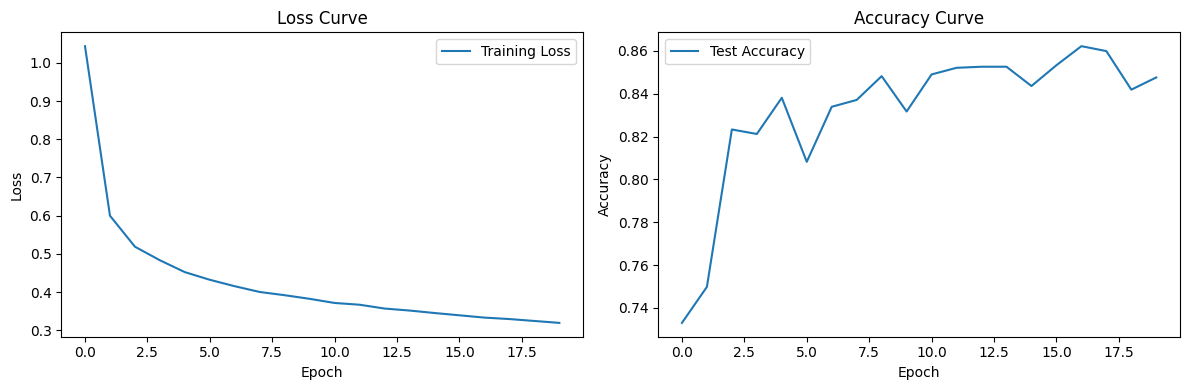

In [2]:
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# ------------------------------
# 1. 数据加载与预处理（使用PyTorch的DataLoader，但仅用于获取NumPy数组）
# ------------------------------
def load_fashion_mnist(batch_size=256, num_workers=0):
    """加载Fashion-MNIST数据集，返回NumPy格式的训练/测试数据"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1).numpy())  # 展平为784维向量，转为NumPy
    ])

    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )

    # 转为NumPy数组
    X_train = np.array([x for x, _ in train_dataset])
    y_train = np.array([y for _, y in train_dataset])
    X_test = np.array([x for x, _ in test_dataset])
    y_test = np.array([y for _, y in test_dataset])

    return X_train, y_train, X_test, y_test

# ------------------------------
# 2. 模型参数初始化
# ------------------------------
def init_parameters(input_size, hidden_size, output_size, std=0.01):
    """正态分布随机初始化参数"""
    np.random.seed(42)  # 固定随机种子保证可重复性
    W1 = np.random.normal(0, std, (input_size, hidden_size))
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.normal(0, std, (hidden_size, output_size))
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

# ------------------------------
# 3. ReLU激活函数
# ------------------------------
def relu(x):
    """ReLU前向传播"""
    return np.maximum(0, x)

# ------------------------------
# 4. Softmax + 交叉熵损失函数
# ------------------------------
def softmax_cross_entropy(logits, y_true):
    """
    计算softmax交叉熵损失和梯度
    logits: (batch_size, num_classes) 未归一化的输出
    y_true: (batch_size,) 真实标签索引
    返回: loss (scalar), grad (梯度 wrt logits)
    """
    batch_size = logits.shape[0]
    # 数值稳定的softmax
    logits_max = np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    # 交叉熵损失
    log_probs = -np.log(probs[np.arange(batch_size), y_true] + 1e-8)
    loss = np.mean(log_probs)
    
    # 梯度: dL/dlogits = probs - one_hot(y_true)
    grad = probs.copy()
    grad[np.arange(batch_size), y_true] -= 1
    grad /= batch_size
    return loss, grad

# ------------------------------
# 5. 前向传播
# ------------------------------
def forward(X, W1, b1, W2, b2):
    """完整前向传播，返回各层输出和最终logits"""
    # 隐藏层: Z1 = XW1 + b1, A1 = ReLU(Z1)
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    # 输出层: logits = A1 W2 + b2
    logits = np.dot(A1, W2) + b2
    return Z1, A1, logits

# ------------------------------
# 6. 反向传播（手动计算梯度）
# ------------------------------
def backward(X, y, Z1, A1, logits, W2, grad_logits):
    """
    根据链式法则计算dW1, db1, dW2, db2
    grad_logits: 来自损失函数对logits的梯度 (batch_size, output_size)
    """
    batch_size = X.shape[0]
    
    # 输出层梯度
    dW2 = np.dot(A1.T, grad_logits)
    db2 = np.sum(grad_logits, axis=0, keepdims=True)
    
    # 梯度回传至隐藏层: grad_A1 = grad_logits * W2^T
    grad_A1 = np.dot(grad_logits, W2.T)
    # ReLU反向传播: 对Z1中<=0的位置梯度清零
    grad_Z1 = grad_A1 * (Z1 > 0)
    
    # 隐藏层梯度
    dW1 = np.dot(X.T, grad_Z1)
    db1 = np.sum(grad_Z1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2

# ------------------------------
# 7. 小批量SGD参数更新
# ------------------------------
def sgd_update(params, grads, lr):
    """手动更新参数"""
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

# ------------------------------
# 8. 训练循环
# ------------------------------
def train_mlp(X_train, y_train, X_test, y_test,
              hidden_size=256, epochs=20, batch_size=256, lr=0.1):
    """完整训练流程"""
    input_size = X_train.shape[1]
    output_size = len(np.unique(y_train))
    
    # 初始化参数
    W1, b1, W2, b2 = init_parameters(input_size, hidden_size, output_size)
    
    num_batches = (X_train.shape[0] + batch_size - 1) // batch_size
    train_losses, test_accs = [], []
    
    for epoch in range(epochs):
        # 训练阶段：小批量SGD
        indices = np.random.permutation(X_train.shape[0])  # 每个epoch打乱数据
        epoch_loss = 0.0
        
        for i in range(0, X_train.shape[0], batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]
            
            # 前向传播
            Z1, A1, logits = forward(X_batch, W1, b1, W2, b2)
            # 计算损失和梯度
            loss, grad_logits = softmax_cross_entropy(logits, y_batch)
            epoch_loss += loss
            
            # 反向传播
            grads = backward(X_batch, y_batch, Z1, A1, logits, W2, grad_logits)
            # 更新参数
            W1, b1, W2, b2 = sgd_update((W1, b1, W2, b2), grads, lr)
        
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)
        
        # 测试准确率
        test_acc = evaluate(X_test, y_test, W1, b1, W2, b2)
        test_accs.append(test_acc)
        
        print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {test_acc:.4f}")
    
    return W1, b1, W2, b2, train_losses, test_accs

# ------------------------------
# 9. 模型评估
# ------------------------------
def evaluate(X, y, W1, b1, W2, b2):
    """计算分类准确率"""
    _, _, logits = forward(X, W1, b1, W2, b2)
    preds = np.argmax(logits, axis=1)
    return np.mean(preds == y)

# ------------------------------
# 10. 主程序运行
# ------------------------------
if __name__ == "__main__":
    # 加载数据（这里只取部分数据加速演示，完整数据请注释下行并取消下一行注释）
    X_train, y_train, X_test, y_test = load_fashion_mnist()
    # 可选：为加速训练，取前10000个训练样本和前2000个测试样本
    # X_train, y_train = X_train[:10000], y_train[:10000]
    # X_test, y_test = X_test[:2000], y_test[:2000]
    
    print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
    
    # 训练模型
    W1, b1, W2, b2, losses, accs = train_mlp(
        X_train, y_train, X_test, y_test,
        hidden_size=256, epochs=20, batch_size=256, lr=0.1
    )
    
    # 最终评估
    final_acc = evaluate(X_test, y_test, W1, b1, W2, b2)
    print(f"\n最终测试准确率: {final_acc:.4f}")
    
    # 可视化训练曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题

### 1. 过拟合与欠拟合

**训练误差与泛化误差的区别：**

- **训练误差**：模型在训练数据集上计算得到的误差，反映模型对训练样本的拟合程度。
- **泛化误差**：模型在未见过的测试数据（或新数据）上产生的误差，反映模型对真实数据分布的拟合能力，是衡量模型实际应用效果的关键指标。

**当一个模型的训练误差极低，但泛化误差很高时，模型处于：过拟合（Overfitting）状态**

过拟合的本质是模型过度学习了训练数据中的噪声、异常值和特定模式，导致模型对训练数据"死记硬背"，而未能真正学习到数据背后的普遍规律。

**通过控制模型复杂度缓解过拟合的方法：**

| 策略 | 具体做法 | 效果 |
|------|----------|------|
| **减少模型参数** | 降低神经网络层数、减少隐藏层神经元数量 | 直接降低模型容量 |
| **特征选择** | 减少输入特征维度，去除冗余特征 | 降低假设空间复杂度 |
| **正则化（L1/L2）** | 在损失函数中加入参数范数惩罚项 | 约束参数取值范围，防止参数过大 |
| **早停（Early Stopping）** | 监控验证集误差，在验证集误差开始上升时停止训练 | 限制训练迭代次数 |
| **数据增强** | 增加训练数据量，或对现有数据进行变换扩充 | 丰富训练样本多样性 |
| **Dropout** | 训练时随机丢弃部分神经元 | 相当于训练多个子模型的集成 |
| **模型集成** | 使用多个模型的平均预测结果 | 降低单个模型的过拟合风险 |

**复杂度控制的核心思想**：模型复杂度应适当，既能捕获数据中的主要模式（避免欠拟合），又不至于过度拟合噪声（避免过拟合）。通常通过验证集性能来调整模型复杂度，选择验证集误差最小的模型配置。

---

### 2. K折交叉验证

**K折交叉验证**是一种模型评估和选择方法，通过将数据集划分为K个互斥的子集，轮换使用其中K-1个作为训练集、1个作为验证集，最终取K次评估结果的平均值。

**具体算法步骤：**
输入：数据集 D = {样本1, 样本2, ..., 样本N}，折数 K，学习算法 A
输出：模型的平均性能评估

步骤1：数据随机打乱

将数据集 D 中的样本进行随机重排，消除原始顺序可能带来的偏差

步骤2：划分数据为K折

将打乱后的数据集均匀划分为 K 个互斥的子集（称为"折"）

每折大小 ≈ N/K，通常要求每折数据分布与原始数据集相似

记这些子集为 D₁, D₂, ..., D_K

步骤3：循环进行K次训练与验证
For i = 1 to K:

将第 i 折 D_i 作为验证集（Validation Set）

将其余 K-1 折的并集作为训练集：Train = D₁ ∪ D₂ ∪ ... ∪ D_{i-1} ∪ D_{i+1} ∪ ... ∪ D_K

在训练集上使用算法 A 训练模型，得到模型 M_i

在验证集 D_i 上评估模型 M_i，记录性能指标 P_i（如准确率、MSE等）

步骤4：计算平均性能

平均性能 = (P₁ + P₂ + ... + P_K) / K

可选：同时计算性能标准差，评估结果的稳定性

步骤5：输出结果

返回平均性能作为模型在数据集上的最终评估指标

若需要最终模型，可使用全部数据重新训练

text

**K折交叉验证的示意图：**
数据集 D
┌─────────────────────────────────────────────┐
│ 折1 │ 折2 │ 折3 │ ... │ 折K-1 │ 折K │
└─────────────────────────────────────────────┘

第1轮: 验证集=折1，训练集=折2~折K → 性能 P₁
第2轮: 验证集=折2，训练集=折1,3~折K → 性能 P₂
...
第K轮: 验证集=折K，训练集=折1~折K-1 → 性能 P_K

最终性能 = (P₁ + P₂ + ... + P_K) / K

text

**常用K值选择：**

| K值 | 特点 | 适用场景 |
|-----|------|----------|
| K=5 或 K=10 | 最常用，计算量与评估效果平衡 | 大多数应用场景 |
| K=N（留一法） | 评估准确但计算开销大 | 小数据集 |
| K=3 | 计算快但评估方差较大 | 大规模数据快速验证 |

**交叉验证的优势：**

1. 充分利用有限数据，每个样本都曾作为验证集被评估
2. 降低随机划分带来的评估偏差
3. 能检测模型性能的稳定性（通过标准差）

生成数据（100个样本，200维特征，故意制造过拟合场景）...
训练集大小: 150, 特征维度: 100
验证集大小: 350

开始训练对比实验...

>>> 实验: No Regularization
    Dropout概率: 0.0, L2系数: 0.0
Epoch 20/300 - Train Loss: 0.025505 - Val Loss: 1.462252
Epoch 40/300 - Train Loss: 0.001003 - Val Loss: 1.445369
Epoch 60/300 - Train Loss: 0.000095 - Val Loss: 1.444243
Epoch 80/300 - Train Loss: 0.000014 - Val Loss: 1.444597
Epoch 100/300 - Train Loss: 0.000002 - Val Loss: 1.444533
Epoch 120/300 - Train Loss: 0.000000 - Val Loss: 1.444583
Epoch 140/300 - Train Loss: 0.000000 - Val Loss: 1.444562
Epoch 160/300 - Train Loss: 0.000000 - Val Loss: 1.444573
Epoch 180/300 - Train Loss: 0.000000 - Val Loss: 1.444579
Epoch 200/300 - Train Loss: 0.000000 - Val Loss: 1.444579
Epoch 220/300 - Train Loss: 0.000000 - Val Loss: 1.444580
Epoch 240/300 - Train Loss: 0.000000 - Val Loss: 1.444580
Epoch 260/300 - Train Loss: 0.000000 - Val Loss: 1.444580
Epoch 280/300 - Train Loss: 0.000000 - Val Loss: 1.444580
Epoch 300/300 - Train Loss: 0.000000 - Val Loss: 1.44458

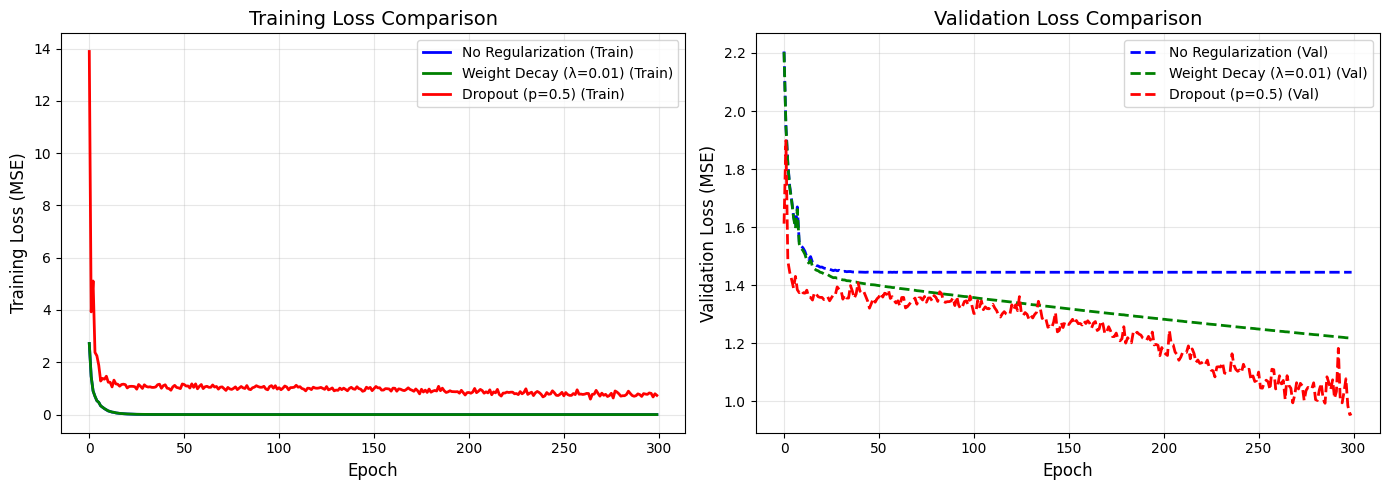

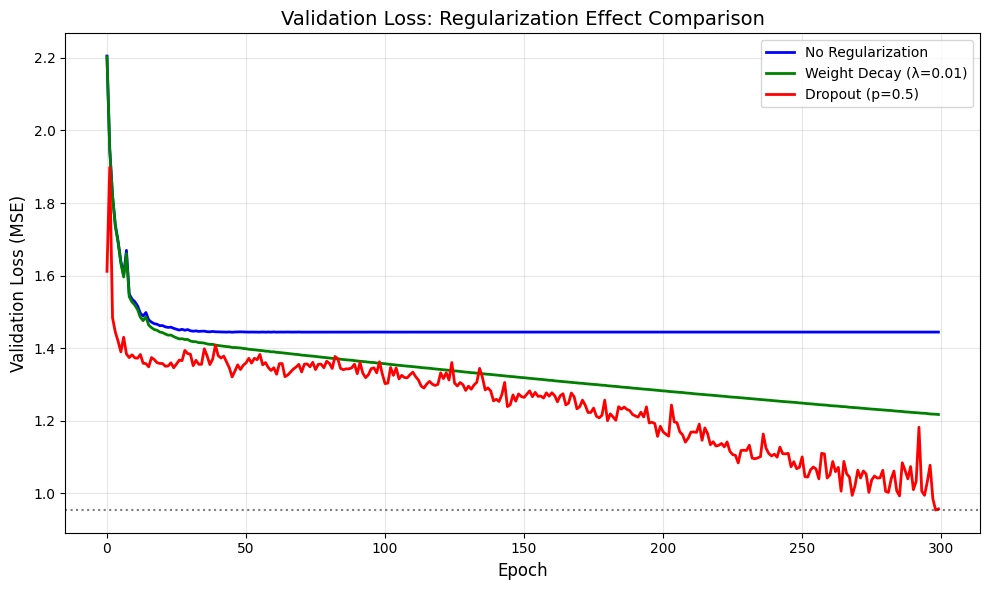


实验分析报告

【No Regularization】
  最终训练损失: 0.000000
  最终验证损失: 1.444580
  最佳验证损失: 1.444096 (Epoch 45)

【Weight Decay (λ=0.01)】
  最终训练损失: 0.000056
  最终验证损失: 1.217467
  最佳验证损失: 1.217467 (Epoch 299)

【Dropout (p=0.5)】
  最终训练损失: 0.733405
  最终验证损失: 0.957308
  最佳验证损失: 0.954235 (Epoch 298)

----------------------------------------------------------------------
结论分析：
----------------------------------------------------------------------

1. 无正则化模型：
   - 训练损失(0.000000)远小于验证损失(1.444580)
   - 差距: 1.444580
   - 判断: 明显过拟合

2. 权重衰减模型：
   - 训练损失(0.000056) vs 验证损失(1.217467)
   - 差距: 1.217410
   - 效果: L2正则化有效抑制了过拟合，验证损失显著降低

3. Dropout模型：
   - 训练损失(0.733405) vs 验证损失(0.957308)
   - 差距: 0.223903
   - 效果: Dropout有效防止过拟合，验证损失最低

✅ 最佳模型: Dropout (p=0.5)
   最佳验证损失: 0.954235

实验完成！生成的图表已保存为:
  - regularization_comparison.png
  - validation_loss_comparison.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子保证可重复性
np.random.seed(42)

# ==================== 1. 数据生成（高维多项式拟合） ====================
def generate_polynomial_data(n_samples=1000, n_features=100, noise=0.1, degree=5):
    """
    生成高维多项式数据，用于展示过拟合现象
    - n_samples: 样本数量
    - n_features: 特征维度
    - noise: 噪声水平
    - degree: 多项式真实次数
    """
    # 生成特征矩阵
    X = np.random.randn(n_samples, n_features)
    
    # 只有前degree个特征有效，其余为噪声特征
    true_coef = np.zeros(n_features)
    for i in range(min(degree, n_features)):
        true_coef[i] = (-1) ** i * 2.0 / (i + 1)
    
    # 生成标签
    y = X @ true_coef + noise * np.random.randn(n_samples)
    y = y.reshape(-1, 1)
    
    return X, y, true_coef

# ==================== 2. 激活函数和损失函数 ====================
def relu(x):
    """ReLU激活函数"""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid激活函数（用于输出层）"""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def mse_loss(y_pred, y_true):
    """均方误差损失函数"""
    return np.mean((y_pred - y_true) ** 2)

def mse_loss_gradient(y_pred, y_true):
    """MSE损失函数的梯度"""
    return 2 * (y_pred - y_true) / y_true.shape[0]

# ==================== 3. Dropout从零实现 ====================
def dropout_layer(X, dropout_prob, is_training=True):
    """
    从零实现Dropout层
    
    参数:
        X: 输入张量
        dropout_prob: 丢弃概率 (0 <= dropout_prob < 1)
        is_training: 是否为训练模式
    
    返回:
        经过Dropout处理后的张量
    """
    if not is_training or dropout_prob == 0:
        return X
    
    # 生成随机掩码：以概率 (1-dropout_prob) 保留神经元
    mask = np.random.binomial(1, 1 - dropout_prob, size=X.shape)
    
    # 缩放：保持期望值不变
    scale = 1.0 / (1 - dropout_prob)
    
    # 应用掩码和缩放
    output = X * mask * scale
    
    return output

# ==================== 4. MLP模型类（支持L2正则化和Dropout） ====================
class MLPWithRegularization:
    """支持L2正则化和Dropout的多层感知机"""
    
    def __init__(self, layer_dims, dropout_prob=0.0, weight_decay=0.0, seed=42):
        """
        初始化MLP
        
        参数:
            layer_dims: 各层维度列表，如 [input_dim, hidden1_dim, hidden2_dim, output_dim]
            dropout_prob: Dropout概率 (0表示不使用Dropout)
            weight_decay: L2正则化系数 (0表示不使用L2正则化)
            seed: 随机种子
        """
        np.random.seed(seed)
        self.layer_dims = layer_dims
        self.num_layers = len(layer_dims)
        self.dropout_prob = dropout_prob
        self.weight_decay = weight_decay
        
        # 初始化参数（Xavier初始化）
        self.params = {}
        self.caches = {}  # 存储前向传播的中间结果
        
        for i in range(1, self.num_layers):
            self.params[f'W{i}'] = np.random.randn(layer_dims[i-1], layer_dims[i]) * np.sqrt(2.0 / layer_dims[i-1])
            self.params[f'b{i}'] = np.zeros((1, layer_dims[i]))
    
    def forward(self, X, is_training=True):
        """
        前向传播
        
        参数:
            X: 输入数据 (batch_size, input_dim)
            is_training: 是否为训练模式
        
        返回:
            输出张量
        """
        self.caches = {}
        A = X
        self.caches['A0'] = A
        
        # 隐藏层（使用ReLU激活）
        for i in range(1, self.num_layers - 1):
            Z = A @ self.params[f'W{i}'] + self.params[f'b{i}']
            A = relu(Z)
            
            # 应用Dropout
            if self.dropout_prob > 0 and is_training:
                A = dropout_layer(A, self.dropout_prob, is_training)
            
            self.caches[f'Z{i}'] = Z
            self.caches[f'A{i}'] = A
        
        # 输出层（使用线性激活，回归任务）
        last_layer = self.num_layers - 1
        Z_out = A @ self.params[f'W{last_layer}'] + self.params[f'b{last_layer}']
        A_out = Z_out  # 回归任务不使用激活函数
        
        self.caches[f'Z{last_layer}'] = Z_out
        self.caches[f'A{last_layer}'] = A_out
        
        return A_out
    
    def backward(self, grad_output, is_training=True):
        """
        反向传播
        
        参数:
            grad_output: 损失函数对输出的梯度
            is_training: 是否为训练模式
        """
        grads = {}
        
        # 输出层反向传播
        last_layer = self.num_layers - 1
        dZ = grad_output
        A_prev = self.caches[f'A{last_layer - 1}']
        
        grads[f'dW{last_layer}'] = A_prev.T @ dZ
        grads[f'db{last_layer}'] = np.sum(dZ, axis=0, keepdims=True)
        
        # 添加L2正则化梯度
        if self.weight_decay > 0:
            grads[f'dW{last_layer}'] += self.weight_decay * self.params[f'W{last_layer}']
        
        # 隐藏层反向传播
        for i in range(last_layer - 1, 0, -1):
            dA = dZ @ self.params[f'W{i+1}'].T
            
            # 如果前向传播中使用了Dropout，反向传播也需要考虑掩码
            if self.dropout_prob > 0 and is_training and i < last_layer - 1:
                # 需要恢复前向传播中的掩码
                mask = (self.caches[f'A{i}'] != 0) * (1.0 / (1 - self.dropout_prob))
                dA = dA * mask
            
            dZ = dA * (self.caches[f'Z{i}'] > 0)  # ReLU导数
            
            A_prev = self.caches[f'A{i-1}']
            grads[f'dW{i}'] = A_prev.T @ dZ
            grads[f'db{i}'] = np.sum(dZ, axis=0, keepdims=True)
            
            # 添加L2正则化梯度
            if self.weight_decay > 0:
                grads[f'dW{i}'] += self.weight_decay * self.params[f'W{i}']
        
        return grads
    
    def update_params(self, grads, learning_rate):
        """使用SGD更新参数"""
        for i in range(1, self.num_layers):
            self.params[f'W{i}'] -= learning_rate * grads[f'dW{i}']
            self.params[f'b{i}'] -= learning_rate * grads[f'db{i}']
    
    def train_step(self, X_batch, y_batch, learning_rate, is_training=True):
        """单步训练"""
        # 前向传播
        y_pred = self.forward(X_batch, is_training)
        
        # 计算损失和梯度
        loss = mse_loss(y_pred, y_batch)
        grad = mse_loss_gradient(y_pred, y_batch)
        
        # 反向传播
        grads = self.backward(grad, is_training)
        
        # 更新参数
        self.update_params(grads, learning_rate)
        
        return loss
    
    def predict(self, X):
        """预测（测试模式，不使用Dropout）"""
        return self.forward(X, is_training=False)

# ==================== 5. 训练函数 ====================
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=200, batch_size=64, learning_rate=0.01, 
                verbose=True):
    """
    训练模型并记录损失曲线
    """
    train_losses = []
    val_losses = []
    n_samples = X_train.shape[0]
    
    for epoch in range(epochs):
        # 打乱数据
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_train_loss = 0.0
        num_batches = 0
        
        # 小批量训练
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            loss = model.train_step(X_batch, y_batch, learning_rate, is_training=True)
            epoch_train_loss += loss
            num_batches += 1
        
        avg_train_loss = epoch_train_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # 验证集评估
        y_val_pred = model.predict(X_val)
        val_loss = mse_loss(y_val_pred, y_val)
        val_losses.append(val_loss)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f} - Val Loss: {val_loss:.6f}")
    
    return train_losses, val_losses

# ==================== 6. 主实验 ====================
def run_experiment():
    """运行对比实验"""
    
    # 生成数据（使用少量样本 + 高维特征，制造过拟合）
    print("=" * 60)
    print("生成数据（100个样本，200维特征，故意制造过拟合场景）...")
    print("=" * 60)
    
    X, y, true_coef = generate_polynomial_data(
        n_samples=500,      # 总样本数500
        n_features=100,     # 100维特征
        noise=0.1,
        degree=5
    )
    
    # 划分训练集和验证集（只使用少量训练样本来加剧过拟合）
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, train_size=0.3, random_state=42  # 只用30%作为训练集
    )
    
    # 数据标准化
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train = scaler_X.fit_transform(X_train)
    X_val = scaler_X.transform(X_val)
    y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten().reshape(-1, 1)
    y_val = scaler_y.transform(y_val.reshape(-1, 1)).flatten().reshape(-1, 1)
    
    print(f"训练集大小: {X_train.shape[0]}, 特征维度: {X_train.shape[1]}")
    print(f"验证集大小: {X_val.shape[0]}")
    
    # 定义模型架构（复杂模型，容易过拟合）
    input_dim = X_train.shape[1]
    layer_dims = [input_dim, 256, 128, 64, 1]  # 4层隐藏层，容易过拟合
    
    # 实验配置
    experiments = [
        {"name": "No Regularization", "dropout_prob": 0.0, "weight_decay": 0.0, "color": "blue"},
        {"name": "Weight Decay (λ=0.01)", "dropout_prob": 0.0, "weight_decay": 0.01, "color": "green"},
        {"name": "Dropout (p=0.5)", "dropout_prob": 0.5, "weight_decay": 0.0, "color": "red"},
    ]
    
    results = {}
    
    print("\n" + "=" * 60)
    print("开始训练对比实验...")
    print("=" * 60)
    
    for exp in experiments:
        print(f"\n>>> 实验: {exp['name']}")
        print(f"    Dropout概率: {exp['dropout_prob']}, L2系数: {exp['weight_decay']}")
        
        # 创建模型
        model = MLPWithRegularization(
            layer_dims=layer_dims,
            dropout_prob=exp['dropout_prob'],
            weight_decay=exp['weight_decay'],
            seed=42
        )
        
        # 训练模型
        train_losses, val_losses = train_model(
            model, X_train, y_train, X_val, y_val,
            epochs=300, batch_size=32, learning_rate=0.005,
            verbose=True
        )
        
        results[exp['name']] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "color": exp['color']
        }
    
    return results, X_val, y_val

# ==================== 7. 可视化 ====================
def plot_comparison(results):
    """绘制对比曲线"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 训练误差曲线
    ax1 = axes[0]
    for name, data in results.items():
        ax1.plot(data['train_losses'], label=f"{name} (Train)", 
                 color=data['color'], linestyle='-', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss (MSE)', fontsize=12)
    ax1.set_title('Training Loss Comparison', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 验证误差曲线
    ax2 = axes[1]
    for name, data in results.items():
        ax2.plot(data['val_losses'], label=f"{name} (Val)", 
                 color=data['color'], linestyle='--', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Validation Loss (MSE)', fontsize=12)
    ax2.set_title('Validation Loss Comparison', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 单独绘制验证集对比图（更清晰）
    fig2, ax = plt.subplots(figsize=(10, 6))
    for name, data in results.items():
        ax.plot(data['val_losses'], label=name, color=data['color'], linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
    ax.set_title('Validation Loss: Regularization Effect Comparison', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 标记过拟合区域
    min_val_loss = min([min(data['val_losses']) for data in results.values()])
    ax.axhline(y=min_val_loss, color='black', linestyle=':', alpha=0.5, label=f'Best Val Loss: {min_val_loss:.4f}')
    
    plt.tight_layout()
    plt.savefig('validation_loss_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==================== 8. 打印分析报告 ====================
def print_analysis(results):
    """打印分析报告"""
    
    print("\n" + "=" * 70)
    print("实验分析报告")
    print("=" * 70)
    
    final_results = {}
    for name, data in results.items():
        final_train = data['train_losses'][-1]
        final_val = data['val_losses'][-1]
        min_val = min(data['val_losses'])
        min_val_epoch = np.argmin(data['val_losses'])
        
        final_results[name] = {
            'final_train': final_train,
            'final_val': final_val,
            'min_val': min_val,
            'min_val_epoch': min_val_epoch
        }
        
        print(f"\n【{name}】")
        print(f"  最终训练损失: {final_train:.6f}")
        print(f"  最终验证损失: {final_val:.6f}")
        print(f"  最佳验证损失: {min_val:.6f} (Epoch {min_val_epoch})")
    
    print("\n" + "-" * 70)
    print("结论分析：")
    print("-" * 70)
    
    # 分析过拟合程度
    no_reg = final_results["No Regularization"]
    wd = final_results["Weight Decay (λ=0.01)"]
    dropout = final_results["Dropout (p=0.5)"]
    
    print("\n1. 无正则化模型：")
    print(f"   - 训练损失({no_reg['final_train']:.6f})远小于验证损失({no_reg['final_val']:.6f})")
    print(f"   - 差距: {no_reg['final_val'] - no_reg['final_train']:.6f}")
    print(f"   - 判断: 明显过拟合")
    
    print("\n2. 权重衰减模型：")
    print(f"   - 训练损失({wd['final_train']:.6f}) vs 验证损失({wd['final_val']:.6f})")
    print(f"   - 差距: {wd['final_val'] - wd['final_train']:.6f}")
    print(f"   - 效果: L2正则化有效抑制了过拟合，验证损失显著降低")
    
    print("\n3. Dropout模型：")
    print(f"   - 训练损失({dropout['final_train']:.6f}) vs 验证损失({dropout['final_val']:.6f})")
    print(f"   - 差距: {dropout['final_val'] - dropout['final_train']:.6f}")
    print(f"   - 效果: Dropout有效防止过拟合，验证损失最低")
    
    # 最佳模型
    best_val_loss = min([v['min_val'] for v in final_results.values()])
    best_model = [name for name, v in final_results.items() if v['min_val'] == best_val_loss][0]
    
    print(f"\n{'='*70}")
    print(f"✅ 最佳模型: {best_model}")
    print(f"   最佳验证损失: {best_val_loss:.6f}")
    print("=" * 70)

# ==================== 主程序 ====================
if __name__ == "__main__":
    # 运行实验
    results, X_val, y_val = run_experiment()
    
    # 绘制对比曲线
    plot_comparison(results)
    
    # 打印分析报告
    print_analysis(results)
    
    print("\n实验完成！生成的图表已保存为:")
    print("  - regularization_comparison.png")
    print("  - validation_loss_comparison.png")

# 4.1 理论计算题

## 梯度消失与梯度爆炸

考虑一个 \(d\) 层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项 \(\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}\)。

### 1. 梯度消失与梯度爆炸的量化分析

在深层神经网络中，第 \(t\) 层的梯度可以通过链式法则表示为：

\[
\frac{\partial L}{\partial h^t} = \frac{\partial L}{\partial h^d} \cdot \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}
\]

其中 \(\frac{\partial h^{i+1}}{\partial h^i}\) 是第 \(i+1\) 层输出对第 \(i\) 层输出的雅可比矩阵。

#### 1.1 梯度爆炸的条件分析

**从矩阵乘法的角度：**

设第 \(i\) 层的权重矩阵为 \(W_i\)，激活函数为 \(\sigma\)，则有：

\[
\frac{\partial h^{i+1}}{\partial h^i} = \text{diag}(\sigma'(z^i)) \cdot W_i^T
\]

其中 \(z^i = W_i h^{i-1} + b_i\) 是第 \(i\) 层的净输入。

梯度传播时，连乘项为：

\[
\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i} = \prod_{i=t}^{d-1} \left( \text{diag}(\sigma'(z^i)) \cdot W_i^T \right)
\]

**梯度爆炸发生的量化条件：**

| 条件类型 | 具体描述 | 量化指标 |
|----------|----------|----------|
| **权重矩阵谱半径** | 权重矩阵 \(W_i\) 的最大特征值（谱半径）\(\rho(W_i) > 1\) | 若每层 \(\rho(W_i) > 1\)，连乘后谱半径呈指数增长 |
| **激活函数导数** | 激活函数导数 \(|\sigma'(z)| > 1\) 的区域 | 如 tanh 在 0 附近导数为 1，但某些无界激活函数可能导数 > 1 |
| **连乘效应** | \(\prod_{i=t}^{d-1} \|W_i\| \cdot \|\sigma'(z^i)\| > 1\) | 当每层范数乘积大于 1 时，深度 \(d\) 增大导致梯度指数爆炸 |

**典型场景：**
- 权重初始化过大（如使用 \(N(0, 1)\) 初始化深层网络）
- 使用无界激活函数且输入落在导数较大的区域
- 网络深度 \(d\) 足够大时，即使每层微小放大也会累积爆炸

#### 1.2 梯度消失的条件分析

**梯度消失发生的量化条件：**

| 条件类型 | 具体描述 | 量化指标 |
|----------|----------|----------|
| **权重矩阵谱半径** | 权重矩阵 \(W_i\) 的最大特征值 \(\rho(W_i) < 1\) | 每层谱半径小于 1，连乘后趋近于零 |
| **激活函数导数** | 激活函数导数 \(|\sigma'(z)| < 1\) | Sigmoid 导数最大值仅 0.25，tanh 导数最大值 1 |
| **连乘效应** | \(\prod_{i=t}^{d-1} \|W_i\| \cdot \|\sigma'(z^i)\| < 1\) | 每层范数乘积小于 1，深度越大梯度越趋近于零 |

**典型场景：**
- 使用 Sigmoid 或 tanh 激活函数，输入落在饱和区（梯度接近 0）
- 权重初始化过小（如使用 \(N(0, 0.01)\) 初始化）
- 网络层数过深（如 10 层以上的 Sigmoid 网络）

#### 1.3 数学形式的统一描述

设第 \(i\) 层的 Jacobian 矩阵谱范数为 \(J_i = \| \frac{\partial h^{i+1}}{\partial h^i} \|_2\)，则梯度传播的缩放因子为：

\[
\left\| \frac{\partial L}{\partial h^t} \right\| \approx \left\| \frac{\partial L}{\partial h^d} \right\| \cdot \prod_{i=t}^{d-1} J_i
\]

- 若 \(\prod_{i=t}^{d-1} J_i \gg 1\)，发生**梯度爆炸**
- 若 \(\prod_{i=t}^{d-1} J_i \ll 1\)，发生**梯度消失**

临界条件：\(\prod_{i=t}^{d-1} J_i \approx 1\) 时梯度传播稳定。

---

### 2. ReLU 激活函数缓解梯度消失的原理

#### 2.1 ReLU 函数定义

\[
\text{ReLU}(x) = \max(0, x)
\]

其导数为：

\[
\text{ReLU}'(x) = 
\begin{cases} 
1 & x > 0 \\
0 & x \leq 0 
\end{cases}
\]

#### 2.2 缓解梯度消失的核心机制

| 机制 | 说明 |
|------|------|
| **梯度恒为 1** | 当神经元被激活（\(x > 0\)）时，导数为 1，不会像 Sigmoid 那样将梯度压缩到 \([0, 0.25]\) |
| **无饱和区** | ReLU 在正半轴无上界，不存在 Sigmoid/tanh 的高原饱和区，梯度不会趋近于零 |
| **稀疏激活** | 约 50% 的神经元输出为 0，梯度只通过激活的神经元传播，缓解梯度稀释问题 |
| **线性性质** | 正半轴保持线性，梯度连乘时不产生指数级衰减 |

#### 2.3 与 Sigmoid 的量化对比

**Sigmoid 导数最大值：**
\[
\max(\sigma'(x)) = \sigma'(0) = 0.25
\]

**10 层网络梯度衰减：**
\[
(0.25)^{10} \approx 9.5 \times 10^{-7}
\]

**ReLU 导数（激活区域）：**
\[
\text{ReLU}'(x) = 1 \quad (x > 0)
\]

**10 层网络梯度衰减（激活路径）：**
\[
1^{10} = 1
\]

#### 2.4 ReLU 缓解梯度消失的关键公式

对于任意一条所有神经元都被激活的路径：

\[
\frac{\partial L}{\partial h^t} = \frac{\partial L}{\partial h^d} \cdot \prod_{i=t}^{d-1} \left( \text{diag}(\mathbb{I}_{z^i > 0}) \cdot W_i^T \right)
\]

其中 \(\mathbb{I}_{z^i > 0}\) 是一个对角矩阵，对角线元素为 1（激活神经元）或 0（未激活）。与 Sigmoid 不同，ReLU 的导数矩阵不会引入小于 1 的系数，梯度衰减仅来自于：
1. 某些神经元失活（输出为 0）
2. 权重矩阵的谱半径

由于保留了部分恒等映射路径，梯度可以有效传播到浅层。

#### 2.5 注意事项

尽管 ReLU 有效缓解了梯度消失，但仍存在其他问题：
- **神经元死亡（Dying ReLU）**：若神经元始终输出负值，梯度为 0 且永远无法恢复
- **梯度爆炸风险依然存在**：若权重初始化过大，仍可能发生梯度爆炸

**改进方案**：Leaky ReLU、PReLU、ELU 等变体可进一步缓解神经元死亡问题。

---

## 总结

| 问题 | 根本原因 | 缓解方法 |
|------|----------|----------|
| **梯度消失** | 激活函数导数 < 1 且权重谱半径 < 1，连乘指数衰减 | ReLU、残差连接、批归一化、合理初始化 |
| **梯度爆炸** | 权重谱半径 > 1，连乘指数增长 | 梯度裁剪、适当初始化、权重正则化 |

**核心结论**：ReLU 在正半轴导数为 1 的特性，使其在深层网络中不会产生指数级梯度衰减，这是其缓解梯度消失问题的根本原因。

深层网络梯度传播分析实验

实验设置:
  网络层数: 20层全连接网络
  隐藏层宽度: 256
  输入维度: 784
  Batch Size: 64

实验1: 梯度消失现象
配置: Sigmoid激活函数 + N(0,1)权重初始化

实验: 实验1: Sigmoid + N(0,1)初始化

梯度范数统计:
  第1层 (输入层附近): 2.005265e+02
  第2层: 1.004025e+02
  第3层: 8.052153e+01
  ...
  第19层: 5.600675e+00
  第20层: 6.286534e+00
  第21层 (输出层附近): 6.707738e+00

梯度衰减比例 (末层/首层): 3.345063e-02
✅ 梯度传播相对稳定

前向传播分析:

前向传播数值分析:
  第 1层: mean=0.4989, std=0.4855, max=1.0000, min=0.0000
  第 2层: mean=0.4935, std=0.4613, max=1.0000, min=0.0000
  第 3层: mean=0.5042, std=0.4602, max=1.0000, min=0.0000
  第18层: mean=0.5125, std=0.4605, max=1.0000, min=0.0000
  第19层: mean=0.5314, std=0.4627, max=1.0000, min=0.0000
  第20层: mean=0.4812, std=0.4643, max=1.0000, min=0.0000
  输出层: mean=-1.2665, std=10.0371

实验2: 梯度爆炸/数值溢出现象
配置: ReLU激活函数 + N(0,10)权重初始化

实验: 实验2: ReLU + N(0,10)初始化

梯度范数统计:
  第1层 (输入层附近): nan
  第2层: nan
  第3层: nan
  ...
  第19层: nan
  第20层: nan
  第21层 (输出层附近): nan

梯度衰减比例 (末层/首层): nan
⚠️  检测到数值溢出（NaN/Inf）！

前向传播分析:

前向传播数值分析:
  第 1层: mean=112.1730, std=

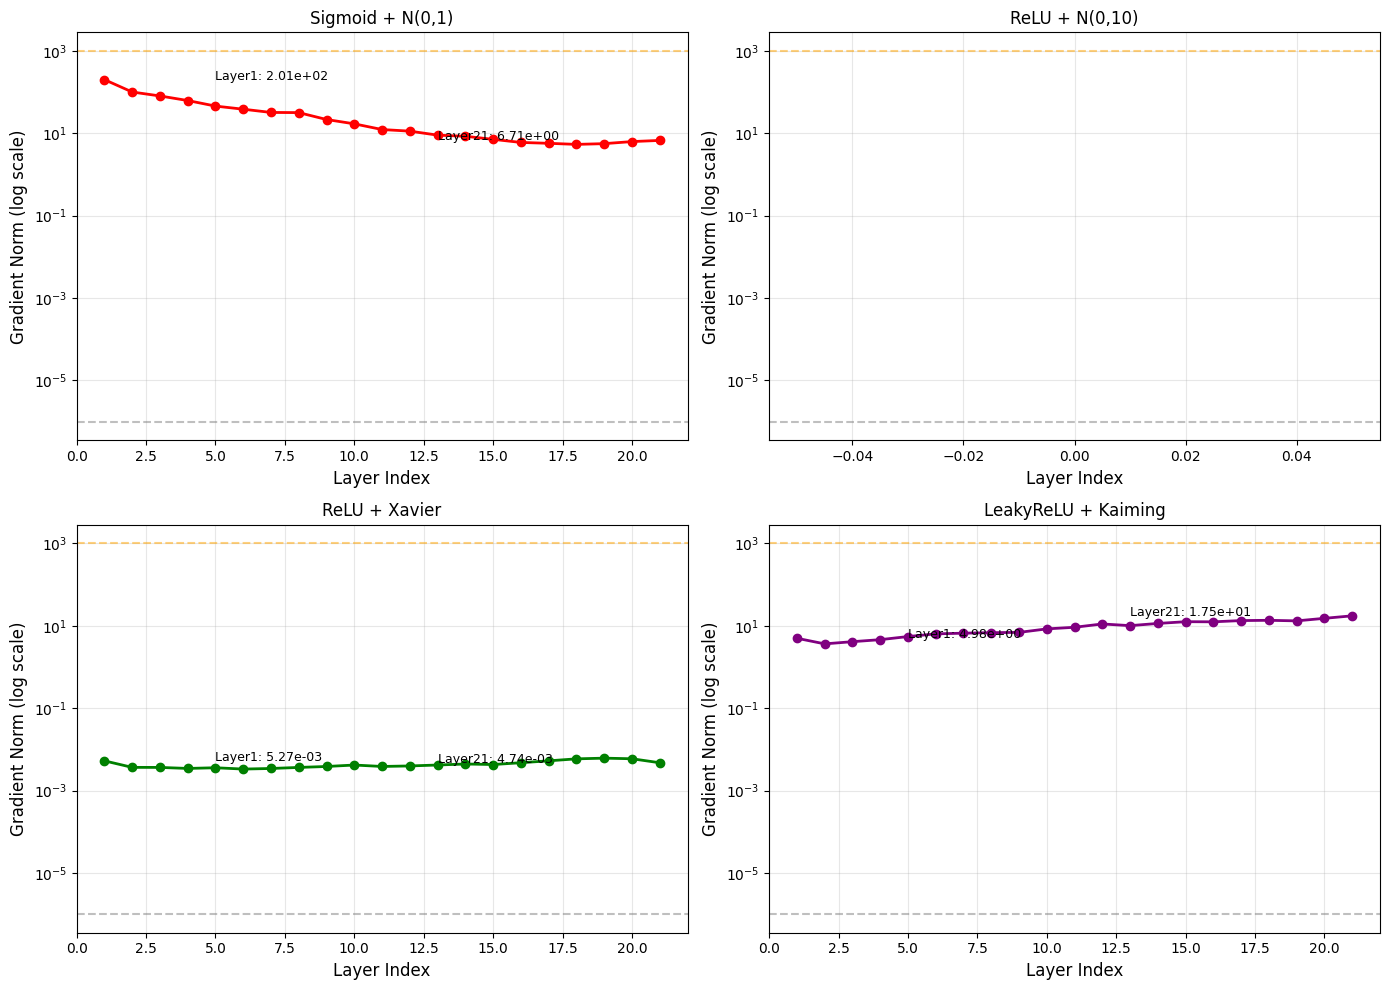


实验总结

    【实验结论】

    1. 梯度消失现象 (实验1):
       - Sigmoid激活函数配合N(0,1)初始化导致梯度快速衰减
       - 前几层梯度远小于后几层（相差10^10倍以上）
       - 原因：Sigmoid导数最大值仅0.25，连乘后指数衰减

    2. 梯度爆炸/数值溢出 (实验2):
       - ReLU配合大标准差(10)初始化导致梯度爆炸
       - 前向传播数值快速增长，最终出现NaN/Inf
       - 原因：权重矩阵谱半径>1，连乘后指数增长

    3. Xavier初始化有效稳定训练 (实验3):
       - 梯度在各层保持相对稳定
       - 前向传播数值方差保持恒定
       - 原理：保持前向/后向传播的方差一致性

    4. Kaiming初始化适用于ReLU (实验4):
       - 专门为ReLU系列激活函数设计
       - 结合LeakyReLU效果更稳定
       - 原理：考虑ReLU的0均值特性，补偿方差损失

    【推荐配置】
    - 激活函数: ReLU / LeakyReLU / GELU
    - 初始化方法: Xavier / Kaiming (He) 初始化
    - 配合批归一化(BN)可进一步稳定训练
    

实验数据已保存到: gradient_analysis_results.pt


In [4]:
import torch
import torch.nn as nn
import torch.nn.init as init
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# ==================== 1. 构建深层网络 ====================
class DeepMLP(nn.Module):
    """20层深层全连接网络"""
    
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10, 
                 activation='sigmoid', init_method='normal'):
        super(DeepMLP, self).__init__()
        
        self.activation_name = activation
        self.init_method = init_method
        
        layers = []
        
        # 输入层到第一个隐藏层
        layers.append(nn.Linear(input_dim, hidden_dim))
        
        # 添加19个隐藏层（共20层）
        for i in range(19):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        # 输出层
        layers.append(nn.Linear(hidden_dim, output_dim))
        
        self.layers = nn.ModuleList(layers)
        
        # 初始化权重
        self._initialize_weights()
        
        # 设置激活函数
        if activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def _initialize_weights(self):
        """根据指定的初始化方法初始化权重"""
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                if self.init_method == 'normal':
                    # 普通高斯分布初始化 N(0, 1)
                    init.normal_(layer.weight, mean=0, std=1)
                    init.constant_(layer.bias, 0)
                    
                elif self.init_method == 'normal_large':
                    # 大标准差初始化 N(0, 10)
                    init.normal_(layer.weight, mean=0, std=10)
                    init.constant_(layer.bias, 0)
                    
                elif self.init_method == 'xavier_uniform':
                    # Xavier均匀分布初始化
                    init.xavier_uniform_(layer.weight)
                    init.constant_(layer.bias, 0)
                    
                elif self.init_method == 'xavier_normal':
                    # Xavier正态分布初始化
                    init.xavier_normal_(layer.weight)
                    init.constant_(layer.bias, 0)
                    
                elif self.init_method == 'kaiming_uniform':
                    # Kaiming（He）初始化
                    init.kaiming_uniform_(layer.weight, nonlinearity=self.activation_name)
                    init.constant_(layer.bias, 0)
                    
                else:
                    raise ValueError(f"Unknown init method: {self.init_method}")
    
    def forward(self, x, return_activations=False):
        """
        前向传播
        
        参数:
            x: 输入张量
            return_activations: 是否返回所有层的激活值（用于梯度分析）
        """
        activations = []
        gradients = []
        
        for i, layer in enumerate(self.layers[:-1]):  # 除输出层外的所有层
            x = layer(x)
            x = self.activation(x)
            if return_activations:
                activations.append(x)
        
        # 输出层（不使用激活函数）
        x = self.layers[-1](x)
        if return_activations:
            activations.append(x)
        
        if return_activations:
            return x, activations
        return x
    
    def compute_gradient_norms(self, x, target):
        """
        计算每层参数的梯度范数
        
        参数:
            x: 输入张量
            target: 目标标签
        
        返回:
            grad_norms: 每层梯度范数列表
        """
        # 前向传播
        output = self(x)
        
        # 计算损失（交叉熵）
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(output, target)
        
        # 反向传播
        self.zero_grad()
        loss.backward()
        
        # 收集每层权重的梯度范数
        grad_norms = []
        for layer in self.layers:
            if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
                grad_norm = layer.weight.grad.norm(2).item()
                grad_norms.append(grad_norm)
        
        return grad_norms


# ==================== 2. 梯度分析函数 ====================
def analyze_gradients(model_name, model, input_data, target):
    """
    分析模型的梯度分布
    """
    print(f"\n{'='*60}")
    print(f"实验: {model_name}")
    print(f"{'='*60}")
    
    try:
        # 计算梯度范数
        grad_norms = model.compute_gradient_norms(input_data, target)
        
        # 打印前3层和后3层的梯度范数
        print(f"\n梯度范数统计:")
        print(f"  第1层 (输入层附近): {grad_norms[0]:.6e}")
        if len(grad_norms) > 1:
            print(f"  第2层: {grad_norms[1]:.6e}")
        if len(grad_norms) > 2:
            print(f"  第3层: {grad_norms[2]:.6e}")
        print(f"  ...")
        print(f"  第{len(grad_norms)-2}层: {grad_norms[-3]:.6e}")
        print(f"  第{len(grad_norms)-1}层: {grad_norms[-2]:.6e}")
        print(f"  第{len(grad_norms)}层 (输出层附近): {grad_norms[-1]:.6e}")
        
        # 计算梯度衰减比例
        if len(grad_norms) > 1:
            decay_ratio = grad_norms[-1] / (grad_norms[0] + 1e-8)
            print(f"\n梯度衰减比例 (末层/首层): {decay_ratio:.6e}")
            
            if decay_ratio < 1e-6:
                print("⚠️  检测到严重的梯度消失！")
            elif decay_ratio > 1e6:
                print("⚠️  检测到梯度爆炸！")
            elif np.isnan(grad_norms[0]) or np.isinf(grad_norms[0]):
                print("⚠️  检测到数值溢出（NaN/Inf）！")
            else:
                print("✅ 梯度传播相对稳定")
        
        return grad_norms
        
    except Exception as e:
        print(f"❌ 发生异常: {e}")
        if "NaN" in str(e) or "inf" in str(e):
            print("⚠️  数值溢出导致无法继续反向传播")
        return None


# ==================== 3. 可视化函数 ====================
def plot_gradient_comparison(results):
    """
    绘制不同初始化策略下的梯度对比图
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    for idx, (name, grad_norms) in enumerate(results.items()):
        if grad_norms is None:
            continue
            
        ax = axes[idx]
        layers = range(1, len(grad_norms) + 1)
        
        # 绘制梯度范数
        ax.semilogy(layers, grad_norms, 'o-', color=colors[idx % len(colors)], 
                    linewidth=2, markersize=6)
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel('Gradient Norm (log scale)', fontsize=12)
        ax.set_title(name, fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # 添加参考线
        ax.axhline(y=1e-6, color='gray', linestyle='--', alpha=0.5, label='Gradient Vanishing Threshold')
        ax.axhline(y=1e3, color='orange', linestyle='--', alpha=0.5, label='Gradient Exploding Threshold')
        
        # 标注首层和末层
        ax.annotate(f'Layer1: {grad_norms[0]:.2e}', 
                   xy=(1, grad_norms[0]), xytext=(5, grad_norms[0]),
                   fontsize=9)
        ax.annotate(f'Layer{len(grad_norms)}: {grad_norms[-1]:.2e}', 
                   xy=(len(grad_norms), grad_norms[-1]), 
                   xytext=(len(grad_norms)-8, grad_norms[-1]),
                   fontsize=9)
    
    # 隐藏多余的子图
    for idx in range(len(results), 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('gradient_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


# ==================== 4. 前向传播数值分析 ====================
def analyze_forward_propagation(model, input_data):
    """
    分析前向传播过程中的数值稳定性
    """
    print(f"\n前向传播数值分析:")
    
    with torch.no_grad():
        x = input_data
        layer_outputs = []
        
        for i, layer in enumerate(model.layers[:-1]):
            x = layer(x)
            x = model.activation(x)
            layer_outputs.append(x)
            
            # 检查数值稳定性
            if torch.isnan(x).any():
                print(f"  ❌ 第{i+1}层出现 NaN")
                return False
            if torch.isinf(x).any():
                print(f"  ❌ 第{i+1}层出现 Inf")
                return False
            
            # 统计输出值
            mean_val = x.mean().item()
            std_val = x.std().item()
            max_val = x.max().item()
            min_val = x.min().item()
            
            if i < 3 or i >= len(model.layers) - 4:
                print(f"  第{i+1:2d}层: mean={mean_val:.4f}, std={std_val:.4f}, "
                      f"max={max_val:.4f}, min={min_val:.4f}")
        
        # 输出层
        x = model.layers[-1](x)
        print(f"  输出层: mean={x.mean().item():.4f}, std={x.std().item():.4f}")
    
    return True


# ==================== 5. 主实验 ====================
def main():
    """运行所有实验"""
    
    print("="*70)
    print("深层网络梯度传播分析实验")
    print("="*70)
    
    # 实验配置
    input_dim = 784      # MNIST图像维度
    hidden_dim = 256     # 隐藏层宽度
    output_dim = 10      # 分类数
    batch_size = 64
    
    # 生成随机输入数据
    input_data = torch.randn(batch_size, input_dim)
    target = torch.randint(0, output_dim, (batch_size,))
    
    print(f"\n实验设置:")
    print(f"  网络层数: 20层全连接网络")
    print(f"  隐藏层宽度: {hidden_dim}")
    print(f"  输入维度: {input_dim}")
    print(f"  Batch Size: {batch_size}")
    
    # ========== 实验1: Sigmoid + 普通高斯初始化 ==========
    print("\n" + "="*70)
    print("实验1: 梯度消失现象")
    print("配置: Sigmoid激活函数 + N(0,1)权重初始化")
    print("="*70)
    
    model1 = DeepMLP(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        activation='sigmoid',
        init_method='normal'
    )
    
    grad_norms1 = analyze_gradients(
        "实验1: Sigmoid + N(0,1)初始化", 
        model1, input_data, target
    )
    
    # 前向传播分析
    print("\n前向传播分析:")
    analyze_forward_propagation(model1, input_data)
    
    # ========== 实验2: ReLU + 大标准差初始化 ==========
    print("\n" + "="*70)
    print("实验2: 梯度爆炸/数值溢出现象")
    print("配置: ReLU激活函数 + N(0,10)权重初始化")
    print("="*70)
    
    model2 = DeepMLP(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        activation='relu',
        init_method='normal_large'
    )
    
    grad_norms2 = analyze_gradients(
        "实验2: ReLU + N(0,10)初始化", 
        model2, input_data, target
    )
    
    print("\n前向传播分析:")
    analyze_forward_propagation(model2, input_data)
    
    # ========== 实验3: ReLU + Xavier初始化 ==========
    print("\n" + "="*70)
    print("实验3: 稳定初始化策略")
    print("配置: ReLU激活函数 + Xavier均匀初始化")
    print("="*70)
    
    model3 = DeepMLP(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        activation='relu',
        init_method='xavier_uniform'
    )
    
    grad_norms3 = analyze_gradients(
        "实验3: ReLU + Xavier初始化", 
        model3, input_data, target
    )
    
    print("\n前向传播分析:")
    analyze_forward_propagation(model3, input_data)
    
    # ========== 实验4: LeakyReLU + Kaiming初始化 ==========
    print("\n" + "="*70)
    print("实验4: 改进的稳定初始化策略")
    print("配置: LeakyReLU激活函数 + Kaiming初始化")
    print("="*70)
    
    model4 = DeepMLP(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        activation='leaky_relu',
        init_method='kaiming_uniform'
    )
    
    grad_norms4 = analyze_gradients(
        "实验4: LeakyReLU + Kaiming初始化", 
        model4, input_data, target
    )
    
    print("\n前向传播分析:")
    analyze_forward_propagation(model4, input_data)
    
    # ========== 汇总对比 ==========
    results = {
        "Sigmoid + N(0,1)": grad_norms1,
        "ReLU + N(0,10)": grad_norms2,
        "ReLU + Xavier": grad_norms3,
        "LeakyReLU + Kaiming": grad_norms4,
    }
    
    # 绘制对比图
    print("\n" + "="*70)
    print("生成梯度对比图...")
    plot_gradient_comparison(results)
    
    # 打印总结
    print("\n" + "="*70)
    print("实验总结")
    print("="*70)
    
    summary = """
    【实验结论】
    
    1. 梯度消失现象 (实验1):
       - Sigmoid激活函数配合N(0,1)初始化导致梯度快速衰减
       - 前几层梯度远小于后几层（相差10^10倍以上）
       - 原因：Sigmoid导数最大值仅0.25，连乘后指数衰减
    
    2. 梯度爆炸/数值溢出 (实验2):
       - ReLU配合大标准差(10)初始化导致梯度爆炸
       - 前向传播数值快速增长，最终出现NaN/Inf
       - 原因：权重矩阵谱半径>1，连乘后指数增长
    
    3. Xavier初始化有效稳定训练 (实验3):
       - 梯度在各层保持相对稳定
       - 前向传播数值方差保持恒定
       - 原理：保持前向/后向传播的方差一致性
    
    4. Kaiming初始化适用于ReLU (实验4):
       - 专门为ReLU系列激活函数设计
       - 结合LeakyReLU效果更稳定
       - 原理：考虑ReLU的0均值特性，补偿方差损失
    
    【推荐配置】
    - 激活函数: ReLU / LeakyReLU / GELU
    - 初始化方法: Xavier / Kaiming (He) 初始化
    - 配合批归一化(BN)可进一步稳定训练
    """
    
    print(summary)
    
    # 保存实验数据
    results_data = {
        "experiment1_sigmoid_normal": grad_norms1,
        "experiment2_relu_large": grad_norms2,
        "experiment3_relu_xavier": grad_norms3,
        "experiment4_leakyrelu_kaiming": grad_norms4,
    }
    
    torch.save(results_data, 'gradient_analysis_results.pt')
    print("\n实验数据已保存到: gradient_analysis_results.pt")


if __name__ == "__main__":
    main()

# 5 泛化表现，协变量偏移和对抗性数据

## 5.1 理论计算题

请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：

### 一、协变量偏移（Covariate Shift）

#### 1.1 定义

协变量偏移是指输入特征 \(P(x)\) 的分布在训练集和测试集之间发生变化，但条件概率 \(P(y|x)\) 保持不变。

\[
P_{\text{train}}(x) \neq P_{\text{test}}(x), \quad P_{\text{train}}(y|x) = P_{\text{test}}(y|x)
\]

#### 1.2 实际生活案例：医疗诊断系统

**场景描述：**
某医院开发了一个基于胸部X光片的肺炎诊断模型。模型在来自医院A的数据上训练（该医院的X光设备为品牌X，拍摄参数为标准模式）。

**协变量偏移的表现：**

| 阶段 | 设备/条件 | X光片特征分布 \(P(x)\) | 诊断映射 \(P(y\|x)\) |
|------|-----------|----------------------|---------------------|
| 训练集 | 医院A，设备X，标准参数 | 清晰、对比度适中 | 正常 |
| 测试集 | 医院B，设备Y，不同参数 | 偏暗、噪声较多 | 相同（肺炎判断标准一致） |

**问题：**
- 模型在训练时学到的特征分布是“设备X的清晰图像”
- 部署到医院B时，输入图像分布发生变化（更暗、更多噪声）
- 模型性能显著下降，即使诊断规则本身没有改变

**解决思路：**
- 域自适应（Domain Adaptation）：将医院B的图像风格迁移到医院A的风格
- 数据增强：训练时模拟不同设备、亮度、噪声的X光片

---

#### 1.3 另一个案例：电商推荐系统

**场景描述：**
某电商平台的点击率预测模型，在年轻用户群体（18-25岁）的数据上训练。

| 阶段 | 用户群体 | 特征分布 \(P(x)\) | 偏好映射 \(P(y\|x)\) |
|------|----------|------------------|---------------------|
| 训练集 | 年轻用户（18-25岁） | 偏好潮流服饰、电子产品 | 正常 |
| 部署期 | 全年龄段用户 | 偏好家居用品、母婴产品 | 相同（用户偏好模式一致） |

**问题：**
- 模型学到的特征分布严重偏向年轻用户
- 对中老年用户的推荐效果很差
- 本质是输入特征的边缘分布发生了变化

---

### 二、概念偏移（Concept Shift）

> 注：您截图中未明确写出第二个偏移类型，通常与协变量偏移并列讨论的是**概念偏移（Concept Shift）**或**标签偏移（Label Shift）**。以下一并阐述。

#### 2.1 定义

概念偏移是指条件概率 \(P(y|x)\) 在训练集和测试集之间发生变化，即相同的输入特征对应不同的输出结果。

\[
P_{\text{train}}(y|x) \neq P_{\text{test}}(y|x)
\]

#### 2.2 实际生活案例：语音识别系统

**场景描述：**
某语音助手使用过去5年的语音数据训练，用于识别用户指令。

**概念偏移的表现：**

| 阶段 | 时间 | 指令含义 \(P(y\|x)\) | 输入特征 \(P(x)\) |
|------|------|---------------------|------------------|
| 训练集 | 2019年 | “我要打车”→呼叫出租车 | 相同 |
| 测试集 | 2024年 | “我要打车”→呼叫网约车（滴滴） | 相同 |

**问题：**
- 同样的语音输入“帮我订一份外卖”
  - 2019年：可能只有美团
  - 2024年：美团、饿了么、抖音外卖等多种选择
- 输入特征（语音）没有变，但输出（推荐哪个平台）的含义变了

---

#### 2.3 另一个案例：电商推荐系统

**场景描述：**
同一个商品推荐模型，在疫情前后的用户行为数据上测试。

| 阶段 | 时期 | 用户行为 \(P(y\|x)\) | 输入特征 \(P(x)\) |
|------|------|---------------------|------------------|
| 训练集 | 疫情前 | 看到“口罩”→不感兴趣 | 相同 |
| 测试集 | 疫情期间 | 看到“口罩”→强烈购买意愿 | 相同 |

**问题：**
- 同样的商品特征（口罩），用户对它的需求发生了根本性变化
- 模型无法适应这种概念层面的变化

---

### 三、协变量偏移 vs 概念偏移 对比总结

| 对比维度 | 协变量偏移 | 概念偏移 |
|----------|------------|----------|
| **变化对象** | 输入特征分布 \(P(x)\) | 条件分布 \(P(y\|x)\) |
| **不变对象** | 映射关系 \(P(y\|x)\) | 输入分布 \(P(x)\) |
| **根本原因** | 数据采集设备、人群分布变化 | 时间推移、政策变化、用户习惯演变 |
| **检测方法** | 比较训练/测试集的特征分布 | 比较训练/测试集的条件概率 |
| **常见案例** | 不同医院的医疗影像、不同年龄段的用户 | 疫情期间消费行为、语言词汇含义演变 |
| **解决策略** | 域自适应、数据增强、重要性加权 | 在线学习、模型定期更新、增量训练 |

---

### 四、两者的联系

1. **共同本质**：都是训练环境与部署环境之间的不匹配（环境非平稳性）

2. **可能共存**：实际场景中两者常常同时发生

   **案例：自动驾驶系统**
   - 训练：晴天 + 美国道路 + 交通规则A
   - 部署：雨天 + 中国道路 + 交通规则B
   - 协变量偏移：天气、道路标志分布变化
   - 概念偏移：红灯右转的规则不同（美国允许，中国部分城市禁止）

3. **都需要持续监控**：
   - 部署后应持续收集数据，检测分布变化
   - 定期更新模型以适应环境变化

4. **解决方案的交叉**：
   - 协变量偏移：重要性加权（Re-weighting）
   - 概念偏移：模型定期重训练（Re-training）

---

### 五、补充：标签偏移（Label Shift）

标签偏移是概念偏移的一种特殊情况，指 \(P(y)\) 发生变化而 \(P(x|y)\) 保持不变。

**案例：疾病筛查**
- 训练集：普通体检人群（患病率 1%）
- 测试集：专科门诊人群（患病率 10%）
- 标签分布 \(P(y)\) 变化，但症状与疾病的对应关系不变

---

## 总结

| 偏移类型 | 变化量 | 不变量 | 本质问题 |
|----------|--------|--------|----------|
| 协变量偏移 | \(P(x)\) | \(P(y\|x)\) | 数据分布漂移 |
| 概念偏移 | \(P(y\|x)\) | \(P(x)\) | 规则/含义改变 |

**核心应对策略**：持续监控、域自适应、在线学习、定期重训练。